Mount Drive


In [21]:
from google.colab import drive
import os

drive.mount('/content/drive')

DATASET_ROOT = "/content/drive/MyDrive/DrivingRiskProject/DrivingRiskDataset/dataset"
RESULTS_DIR = "/content/drive/MyDrive/DrivingRiskProject/results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print(os.listdir(DATASET_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['5 star', '4 star', '3 star', '2 star', '1 star', 'testing']


Imports

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.calibration import calibration_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

Settings

In [29]:
WINDOW_SIZE = 120
STEP_SIZE = 20

SENSOR_COLS = ['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']

Load Dataset

In [30]:
def load_dataset(root):
    all_dfs = []

    for star in range(1, 6):
        folder = Path(root) / f"{star} star"

        for path in folder.glob("*.csv"):
            df = pd.read_csv(path)

            if all(col in df.columns for col in SENSOR_COLS):
                df['star_label'] = star - 1
                df['source_file'] = path.name
                all_dfs.append(df[SENSOR_COLS + ['star_label', 'source_file']])

    return pd.concat(all_dfs, ignore_index=True)

Windowing

In [31]:
def make_windows(df):
    X_list, y_list = [], []

    for name, group in df.groupby('source_file'):
        label = group['star_label'].iloc[0]
        values = group[SENSOR_COLS].values.astype(np.float32)

        for i in range(0, len(values) - WINDOW_SIZE + 1, STEP_SIZE):
            X_list.append(values[i:i+WINDOW_SIZE])
            y_list.append(label)

    return np.array(X_list), np.array(y_list)

Data Prep

In [32]:
df_raw = load_dataset(DATASET_ROOT)

X, y = make_windows(df_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, 6))

X_train_n = scaler.transform(X_train.reshape(-1, 6)).reshape(len(X_train), WINDOW_SIZE, 6)
X_test_n = scaler.transform(X_test.reshape(-1, 6)).reshape(len(X_test), WINDOW_SIZE, 6)

print("Train:", X_train_n.shape)
print("Test:", X_test_n.shape)

Train: (120396, 120, 6)
Test: (30100, 120, 6)


LSTM Model

In [33]:
def build_lstm():
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=(WINDOW_SIZE, 6)),
        Dropout(0.3),
        BatchNormalization(),

        Bidirectional(LSTM(64)),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

Train LSTM

In [34]:
lstm_model = build_lstm()

lstm_history = lstm_model.fit(
    X_train_n,
    to_categorical(y_train, 5),
    validation_split=0.15,
    epochs=50,
    batch_size=64,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.4949 - loss: 1.1740 - val_accuracy: 0.6276 - val_loss: 0.8913
Epoch 2/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.6547 - loss: 0.8460 - val_accuracy: 0.7272 - val_loss: 0.6740
Epoch 3/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.7195 - loss: 0.6955 - val_accuracy: 0.7401 - val_loss: 0.6322
Epoch 4/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.7557 - loss: 0.6045 - val_accuracy: 0.7861 - val_loss: 0.5341
Epoch 5/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 55s 34ms/step - accuracy: 0.7801 - loss: 0.5482 - val_accuracy: 0.8072 - val_loss: 0.4776
Epoch 6/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.7984 - loss: 0.5031 - val_accuracy: 0.8202 - val_loss: 0.4343
Epoch 7/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 91s 40ms/step - accuracy: 0.8117 - loss: 0.4651 - val_accuracy: 0.8214 - val_loss: 0.4396
Epoch 8/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.8210 -

Transformer Model

In [35]:
from tensorflow.keras import layers, models

def transformer_encoder(x):
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = layers.LayerNormalization()(x + attn)

    ff = layers.Dense(256, activation="relu")(x)
    ff = layers.Dropout(0.3)(ff)
    ff = layers.Dense(x.shape[-1])(ff)

    return layers.LayerNormalization()(x + ff)


def build_transformer(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.Dense(128)(inputs)

    x = transformer_encoder(x)
    x = transformer_encoder(x)
    x = transformer_encoder(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(64, activation="relu")(x)

    outputs = layers.Dense(5, activation="softmax")(x)

    return models.Model(inputs, outputs)


transformer_model = build_transformer((WINDOW_SIZE, 6))

transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(transformer_model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 120, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 120, 128)  │        896 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 120, 128)  │    131,968 │ dense_10[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 120, 128)  │          0 │ dense_10[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 128)  │        256 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 120, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 120, 256)  │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 120, 128)  │     32,896 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 120, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 128)  │        256 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 120, 128)  │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 120, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 128)  │        256 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 120, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 120, 256)  │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 120, 128)  │     32,896 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 120, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 128)  │        256 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 621,189 (2.37 MB)

 Trainable params: 621,189 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

None


Train Transformer

In [37]:
transformer_history = transformer_model.fit(
    X_train_n,
    to_categorical(y_train, 5),
    validation_split=0.15,
    epochs=50,
    batch_size=64
)

Epoch 1/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.7931 - loss: 0.5055 - val_accuracy: 0.7997 - val_loss: 0.4858
Epoch 2/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.8061 - loss: 0.4725 - val_accuracy: 0.8169 - val_loss: 0.4374
Epoch 3/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8153 - loss: 0.4527 - val_accuracy: 0.8107 - val_loss: 0.4575
Epoch 4/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8253 - loss: 0.4269 - val_accuracy: 0.8296 - val_loss: 0.4129
Epoch 5/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8301 - loss: 0.4165 - val_accuracy: 0.8337 - val_loss: 0.4046
Epoch 6/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8359 - loss: 0.4021 - val_accuracy: 0.8367 - val_loss: 0.3926
Epoch 7/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.8381 - loss: 0.3948 - val_accuracy: 0.8440 - val_loss: 0.3776
Epoch 8/50
1599/1599 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.8419 -

Evaluation

In [38]:
print("LSTM:")
print(classification_report(y_test, np.argmax(lstm_model.predict(X_test_n), axis=1)))

print("Transformer:")
print(classification_report(y_test, np.argmax(transformer_model.predict(X_test_n), axis=1)))

LSTM:
941/941 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      6561
           1       0.97      0.93      0.95      4978
           2       0.98      0.87      0.92      7005
           3       0.92      0.89      0.90      7697
           4       0.80      0.86      0.83      3859

    accuracy                           0.90     30100
   macro avg       0.90      0.90      0.90     30100
weighted avg       0.91      0.90      0.90     30100

Transformer:
941/941 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      6561
           1       0.97      0.91      0.94      4978
           2       0.95      0.88      0.91      7005
           3       0.86      0.91      0.88      7697
           4       0.85      0.81      0.83      3859

    accuracy                           0.89     30100
   macro avg       0.89      0

Confusion Matrix (Both Models)

941/941 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step
941/941 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step


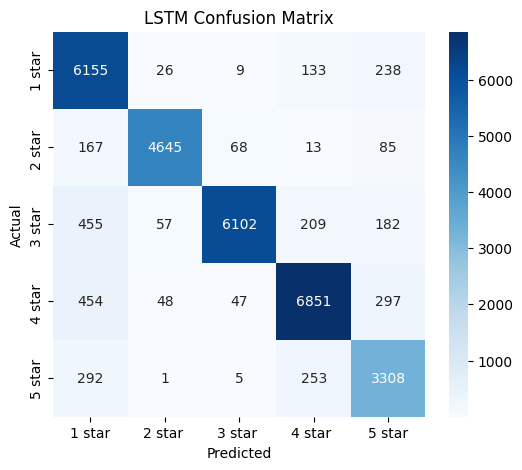

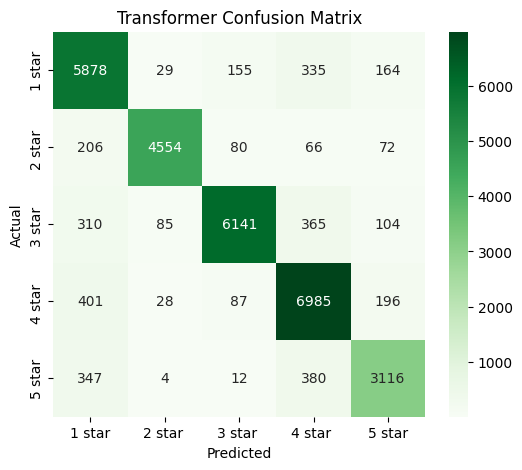

In [73]:
# ================= CONFUSION MATRIX (BOTH MODELS) =================
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predictions
l_pred = np.argmax(lstm_model.predict(X_test_n), axis=1)
t_pred = np.argmax(transformer_model.predict(X_test_n), axis=1)

# Confusion matrices
cm_lstm = confusion_matrix(y_test, l_pred)
cm_trans = confusion_matrix(y_test, t_pred)

labels = ['1 star','2 star ','3 star ','4 star ','5 star']

# Plot LSTM
plt.figure(figsize=(6,5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot Transformer
plt.figure(figsize=(6,5))
sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy Comparison

In [39]:
lstm_acc = lstm_model.evaluate(X_test_n, to_categorical(y_test, 5), verbose=0)[1]
transformer_acc = transformer_model.evaluate(X_test_n, to_categorical(y_test, 5), verbose=0)[1]

print("LSTM:", lstm_acc)
print("Transformer:", transformer_acc)

LSTM: 0.8990365266799927
Transformer: 0.8861793875694275


Accuracy Graph

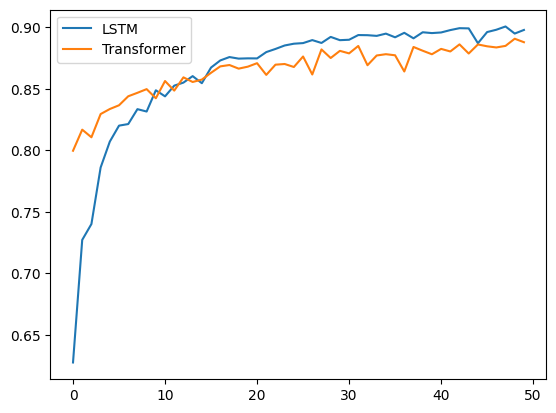

In [40]:
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.plot(transformer_history.history['val_accuracy'], label='Transformer')
plt.legend()
plt.show()

Confidence

In [45]:


# Transformer
t_probs = transformer_model.predict(X_test_n)
t_conf = np.max(t_probs, axis=1)
t_pred = np.argmax(t_probs, axis=1)
t_correct = (t_pred == y_test)

# LSTM
l_probs = lstm_model.predict(X_test_n)
l_conf = np.max(l_probs, axis=1)
l_pred = np.argmax(l_probs, axis=1)
l_correct = (l_pred == y_test)

print("=== TRANSFORMER ===")
print("Avg Confidence:", np.mean(t_conf))
print("Accuracy:", np.mean(t_correct))

print("\n=== LSTM ===")
print("Avg Confidence:", np.mean(l_conf))
print("Accuracy:", np.mean(l_correct))

941/941 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
941/941 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step
=== TRANSFORMER ===
Avg Confidence: 0.89090246
Accuracy: 0.8861794019933554

=== LSTM ===
Avg Confidence: 0.9032838
Accuracy: 0.8990365448504983


Calibration Curve

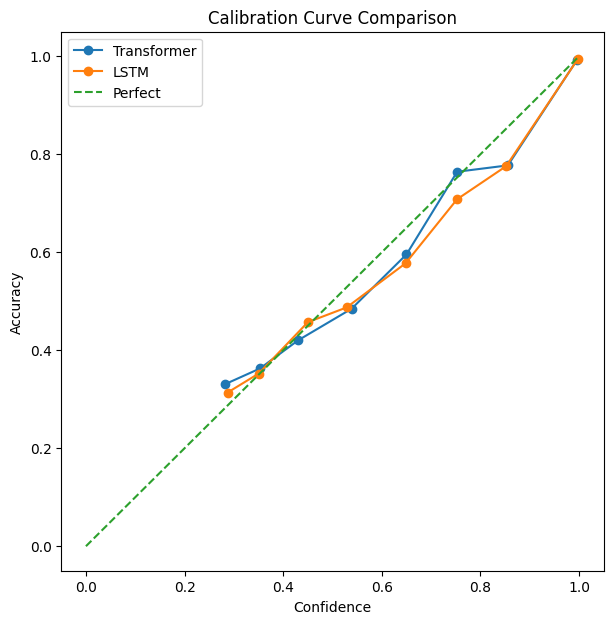

In [70]:

from sklearn.calibration import calibration_curve

# Transformer
t_prob_true, t_prob_pred = calibration_curve(t_correct, t_conf, n_bins=10)

# LSTM
l_prob_true, l_prob_pred = calibration_curve(l_correct, l_conf, n_bins=10)

# Plot
plt.figure(figsize=(7,7))

plt.plot(t_prob_pred, t_prob_true, marker='o', label='Transformer')
plt.plot(l_prob_pred, l_prob_true, marker='o', label='LSTM')
plt.plot([0,1], [0,1], '--', label='Perfect')

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.show()

CSV Testing

In [63]:
def calculate_driving_score(preds):
    avg = np.mean(preds, axis=0)
    return np.dot(avg, [20,40,60,80,100])


def get_status(score):
    if score >= 90:
        return "SMOOTH "
    elif score >= 80:
        return "SAFEST "
    elif score >= 60:
        return "SAFE "
    elif score >= 40:
        return "RISKY "
    else:
        return "DANGEROUS "


def run_test(file, model, name):
    df = pd.read_csv(file)
    data = df[SENSOR_COLS].values

    # Create windows
    windows = [
        data[i:i+WINDOW_SIZE]
        for i in range(0, len(data)-WINDOW_SIZE, STEP_SIZE)
    ]

    X_input = np.array(windows)

    # Normalize
    X_input = scaler.transform(X_input.reshape(-1,6)).reshape(len(windows), WINDOW_SIZE, 6)

    # Predict
    preds = model.predict(X_input)

    # Score
    score = calculate_driving_score(preds)

    # Confidence
    avg_probs = np.mean(preds, axis=0)
    conf = np.max(avg_probs)

    # Star rating (1–5)
    star = np.argmax(avg_probs) + 1

    # Status
    status = get_status(score)

    # Output
    print("\n==============================")
    print(f" File: {file.split('/')[-1]}")
    print(f" Model: {name}")
    print(f" Rating: {star}")
    print(f" Driving Score: {score:.2f}/100")
    print(f" Status: {status}")
    print(f" Confidence: {conf:.2f}")
    print("==============================")

CSV Testing

In [71]:
test_file = f"{DATASET_ROOT}/testing/Sanjay_5star.csv"

run_test(test_file, lstm_model, "LSTM")
run_test(test_file, transformer_model, "Transformer")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

 File: Sanjay_5star.csv
 Model: LSTM
 Rating: 5
 Driving Score: 99.39/100
 Status: SMOOTH 
 Confidence: 0.99
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step

 File: Sanjay_5star.csv
 Model: Transformer
 Rating: 5
 Driving Score: 94.40/100
 Status: SMOOTH 
 Confidence: 0.91


Data  Visualization for verification

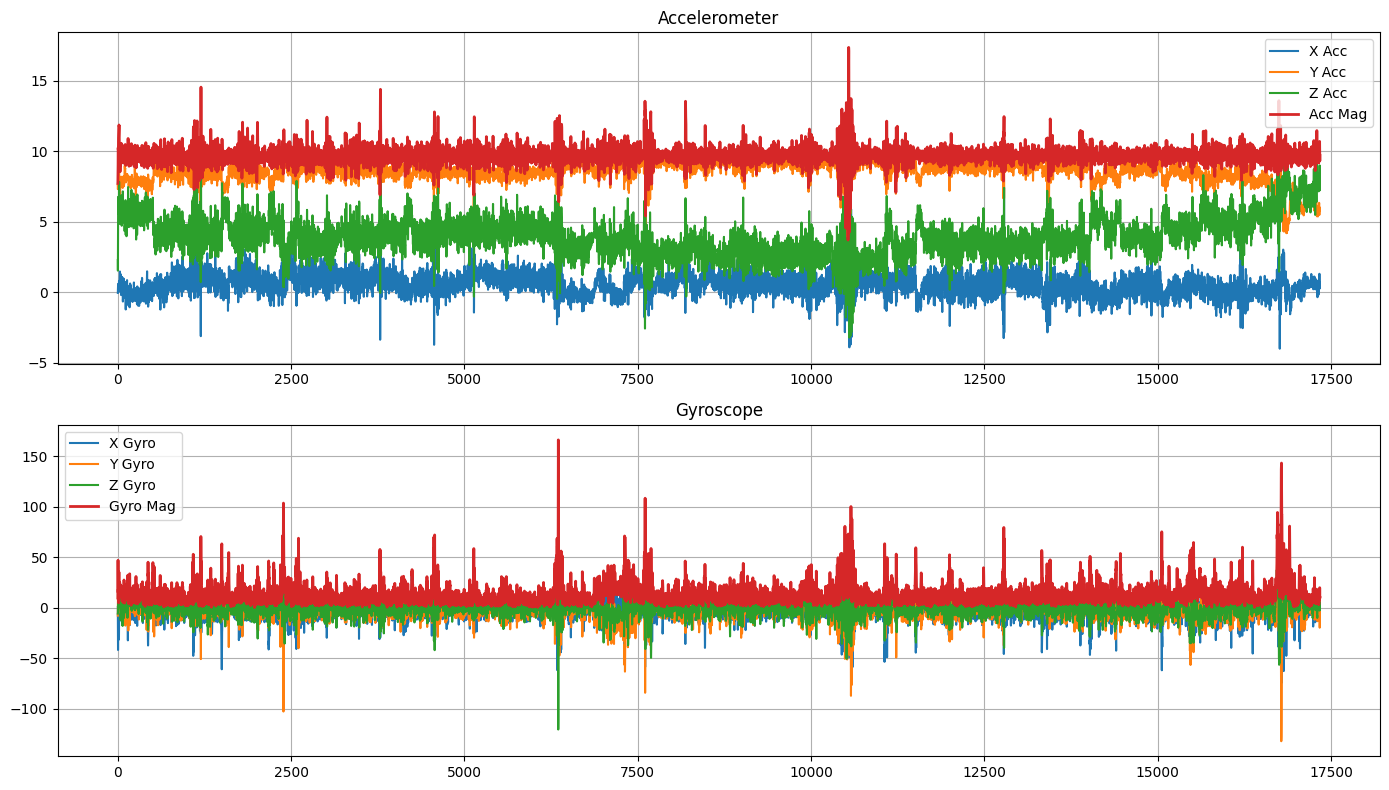

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def visualize_csv(file_path):
    df = pd.read_csv(file_path)

    # Add magnitude features
    df['Acc_Mag'] = np.sqrt(df['X_Acc']**2 + df['Y_Acc']**2 + df['Z_Acc']**2)
    df['Gyro_Mag'] = np.sqrt(df['X_Gyro']**2 + df['Y_Gyro']**2 + df['Z_Gyro']**2)

    plt.figure(figsize=(14, 8))

    # Accelerometer
    plt.subplot(2, 1, 1)
    plt.plot(df['X_Acc'], label='X Acc')
    plt.plot(df['Y_Acc'], label='Y Acc')
    plt.plot(df['Z_Acc'], label='Z Acc')
    plt.plot(df['Acc_Mag'], label='Acc Mag', linewidth=2)
    plt.title("Accelerometer")
    plt.legend()
    plt.grid()

    # Gyroscope
    plt.subplot(2, 1, 2)
    plt.plot(df['X_Gyro'], label='X Gyro')
    plt.plot(df['Y_Gyro'], label='Y Gyro')
    plt.plot(df['Z_Gyro'], label='Z Gyro')
    plt.plot(df['Gyro_Mag'], label='Gyro Mag', linewidth=2)
    plt.title("Gyroscope")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()
test_file = f"{DATASET_ROOT}/testing/Sanjay_5star.csv"

if os.path.exists(test_file):

    #  Step 1: Visualize
    visualize_csv(test_file)
